# The Eras Tour of Computer Vision
## Era 1: The Rules Era (Workshop Edition)

Welcome to the first era of the tour. Before neural networks, computer vision meant writing
down, explicitly, what you were looking for: "mugs are roughly this color, roughly this shape."

This notebook already runs end to end. Your job in the next few minutes is to **tweak two
numbers** and watch what happens. That's it. No blank functions, no starting from scratch.

Look for cells marked `# TRY CHANGING ME` -- those are the only lines you need to touch.

## Setup

Run this first. If you're in Colab, this also mounts Google Drive -- but since we're using a
public dataset, you can skip that and just clone the repo instead (already done below).

In [1]:
!git clone -q https://github.com/LinoNU/eras-tour-workshop.git 2>/dev/null || echo 'Already cloned'
%cd eras-tour-workshop

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('data')
labels_df = pd.read_csv(DATA_DIR / 'labels.csv')
print(f"Loaded {len(labels_df)} images across {labels_df['tier'].nunique()} tiers.")

/content/eras-tour-workshop
Loaded 50 images across 6 tiers.


In [15]:
def load_image(rel_path: str) -> np.ndarray:
    """Load an image as an RGB NumPy array."""
    filepath = str(DATA_DIR / rel_path)
    print(filepath)
    image_bgr = cv2.imread(filepath)
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def load_image_abs(filepath: str) -> np.ndarray:
    """Load an image as an RGB NumPy array."""
    image_bgr = cv2.imread(filepath)
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def show_image(image: np.ndarray, title: str = '') -> None:
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(title, fontsize=9)
    plt.axis('off')
    plt.show()

## The detector (already built for you)

This is a full classical CV pipeline: color thresholding, morphological cleanup, contour
detection, and a shape filter. You don't need to write any of this. Just look at the two
`# TRY CHANGING ME` lines below.

In [12]:
def color_mask(image: np.ndarray) -> np.ndarray:
    """Return a binary mask of pixels that plausibly belong to a mug."""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # White/light ceramic range.
    lower_white = np.array([0, 0, 150])
    upper_white = np.array([179, 60, 255])
    mask_white = cv2.inRange(hsv, lower_white, upper_white)

    # TRY CHANGING ME: this range is tuned for a BLUE mug. If your test image is a
    # different color, try widening the hue range (first number in each array) and
    # see what happens. Hue runs 0-179 in OpenCV: reds near 0/179, greens ~60,
    # blues ~120.
    lower_colored = np.array([95, 80, 60])   # TRY CHANGING ME (currently: blue-ish)
    upper_colored = np.array([130, 255, 255])  # TRY CHANGING ME
    mask_colored = cv2.inRange(hsv, lower_colored, upper_colored)

    mask = cv2.bitwise_or(mask_white, mask_colored)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


def find_candidate_contours(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return list(contours)


def contour_circularity(contour) -> float:
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, closed=True)
    return float(4 * np.pi * area / (perimeter ** 2)) if perimeter else 0.0


def is_mug_shaped(contour, image_area: int) -> bool:
    area = cv2.contourArea(contour)
    relative_area = area / image_area
    MIN_RELATIVE_AREA = 0.05
    MAX_RELATIVE_AREA = 0.55
    MIN_CIRCULARITY = 0.35  # TRY CHANGING ME: lower = more forgiving of odd shapes
    if not (MIN_RELATIVE_AREA <= relative_area <= MAX_RELATIVE_AREA):
        return False
    return contour_circularity(contour) >= MIN_CIRCULARITY


def detect_mug(image: np.ndarray) -> dict:
    mask = color_mask(image)
    contours = find_candidate_contours(mask)
    image_area = image.shape[0] * image.shape[1]
    accepted = [c for c in contours if is_mug_shaped(c, image_area)]
    return {'prediction': len(accepted) > 0, 'accepted_contours': accepted}


def visualize_detection(image: np.ndarray, result: dict, title: str = '') -> None:
    annotated = image.copy()
    cv2.drawContours(annotated, result['accepted_contours'], -1, (255, 0, 0), 3)
    show_image(annotated, title=f"{title} | predicted={result['prediction']}")

In [21]:
def multi_color_mask(image: np.ndarray) -> np.ndarray:
    """Union of several plausible mug-color ranges (white/light ceramic + common hues)."""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    ranges = [
        ((0, 0, 150), (179, 60, 255)),     # white/light ceramic
        ((95, 80, 60), (130, 255, 255)),   # blue
        ((0, 80, 60), (10, 255, 255)),     # red (low wrap)
        ((170, 80, 60), (179, 255, 255)),  # red (high wrap)
        ((20, 80, 60), (35, 255, 255)),    # yellow
        ((35, 60, 40), (85, 255, 255)),    # green
    ]
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lo, hi in ranges:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, np.array(lo), np.array(hi)))
    return mask


def edge_mask(image: np.ndarray) -> np.ndarray:
    """Closed edge map — catches mug boundaries color segmentation misses."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    kernel = np.ones((7, 7), np.uint8)
    return cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)


def combined_mask(image: np.ndarray) -> np.ndarray:
    """Fuse color and edge cues, then clean up with morphology."""
    mask = cv2.bitwise_or(multi_color_mask(image), edge_mask(image))
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


def contour_circularity(contour) -> float:
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, closed=True)
    return float(4 * np.pi * area / (perimeter ** 2)) if perimeter else 0.0


def contour_aspect_ratio(contour) -> float:
    _, _, w, h = cv2.boundingRect(contour)
    return h / w if w else 0.0


def has_handle_like_defect(contour) -> bool:
    """Look for a convexity defect deep enough to plausibly be a handle."""
    hull = cv2.convexHull(contour, returnPoints=False)
    if hull is None or len(hull) < 4:
        return False
    try:
        defects = cv2.convexityDefects(contour, hull)
    except cv2.error:
        return False
    if defects is None:
        return False
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return False

    defects = defects.reshape(-1, 4)  # normalize to (N, 4) regardless of OpenCV version
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return False
    max_depth = defects[:, 3].max() / 256.0
    return max_depth > 0.03 * perimeter

def is_mug_shaped2(contour, image_area: int) -> bool:
    area = cv2.contourArea(contour)
    relative_area = area / image_area
    MIN_RELATIVE_AREA = 0.05
    MAX_RELATIVE_AREA = 0.55
    MIN_CIRCULARITY = 0.30
    MIN_ASPECT, MAX_ASPECT = 0.6, 2.0  # tolerant of viewing angle

    if not (MIN_RELATIVE_AREA <= relative_area <= MAX_RELATIVE_AREA):
        return False
    if contour_circularity(contour) < MIN_CIRCULARITY:
        return False
    aspect = contour_aspect_ratio(contour)
    if not (MIN_ASPECT <= aspect <= MAX_ASPECT):
        return False
    return True  # handle defect used as a soft bonus, not a hard gate


def score_contour(contour, image_area: int) -> float:
    """Higher score = more mug-like. Used to rank multiple accepted candidates."""
    score = contour_circularity(contour)
    if has_handle_like_defect(contour):
        score += 0.5
    return score


def detect_mug2(image: np.ndarray) -> dict:
    mask = combined_mask(image)
    contours = find_candidate_contours(mask)
    image_area = image.shape[0] * image.shape[1]

    accepted = [c for c in contours if is_mug_shaped2(c, image_area)]
    accepted.sort(key=lambda c: score_contour(c, image_area), reverse=True)

    return {'prediction': len(accepted) > 0, 'accepted_contours': accepted}

## Try it now

Pick a few images below and see what the detector says. Then go back up, change the two
marked lines, re-run both cells, and see what changes.

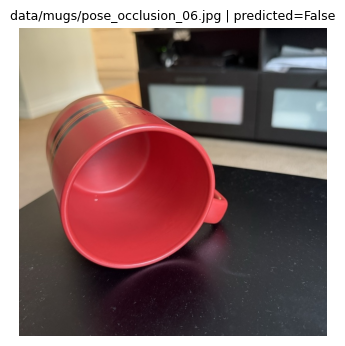

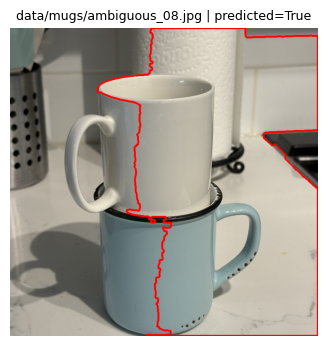

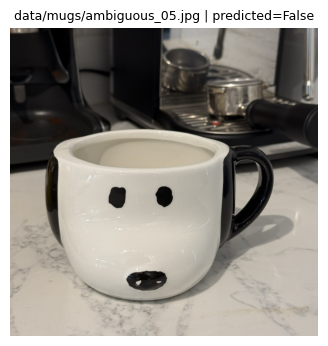

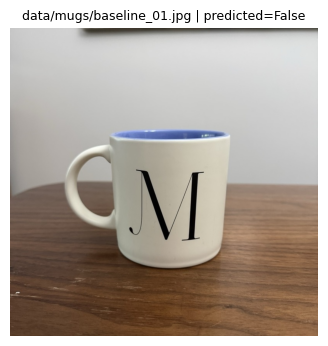

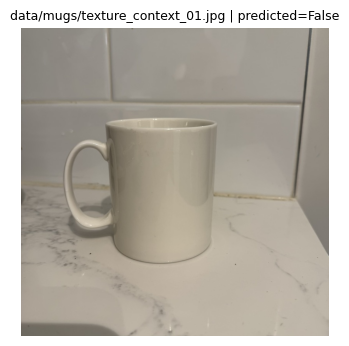

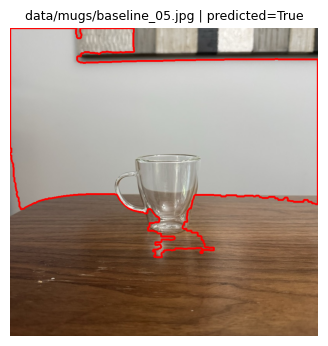

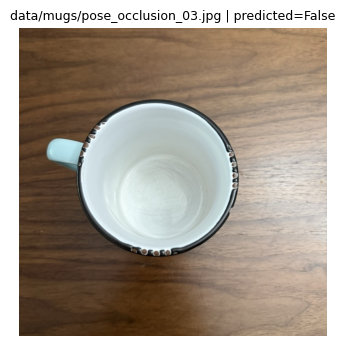

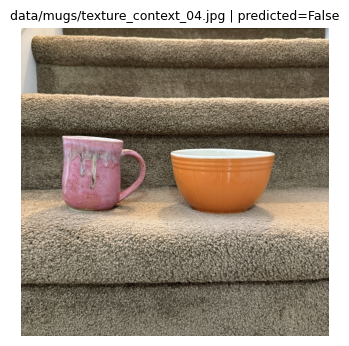

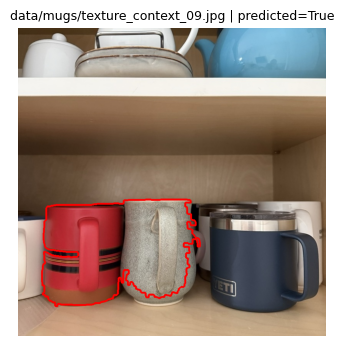

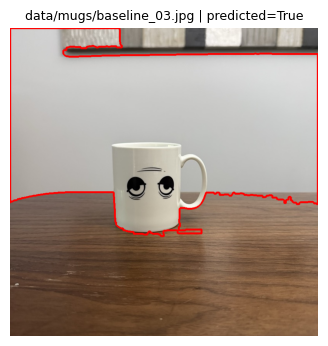

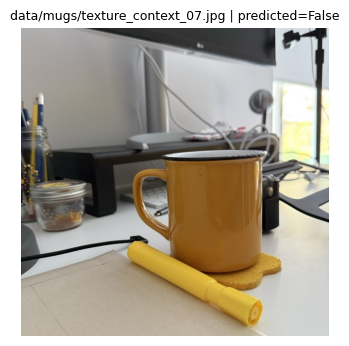

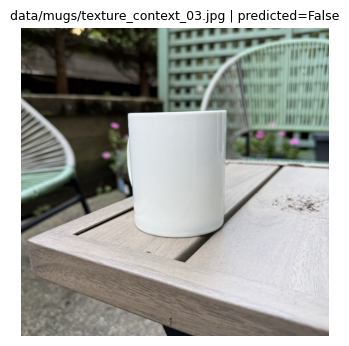

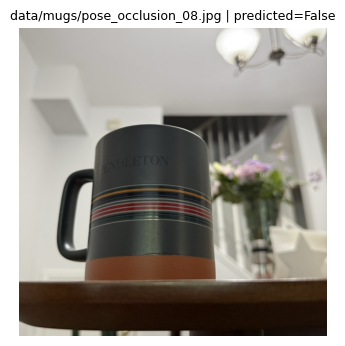

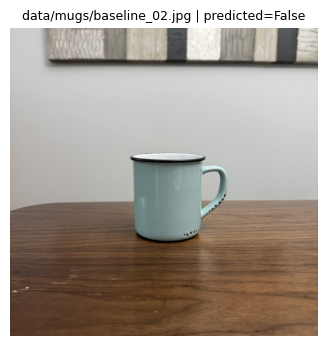

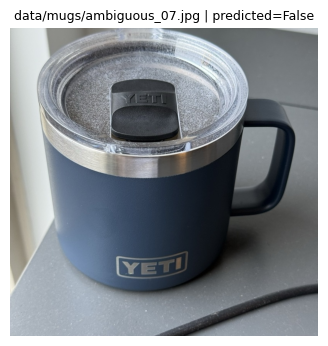

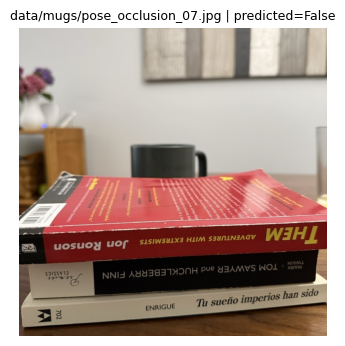

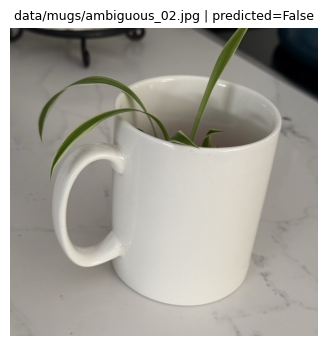

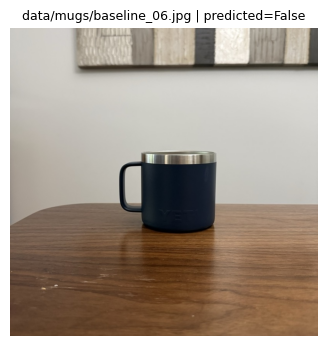

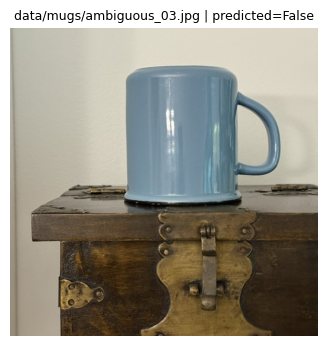

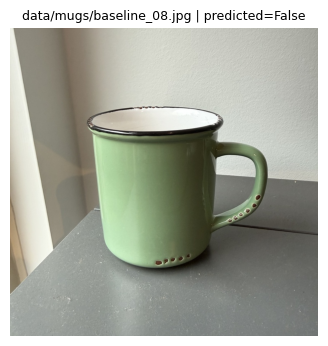

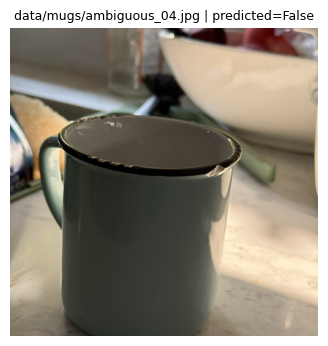

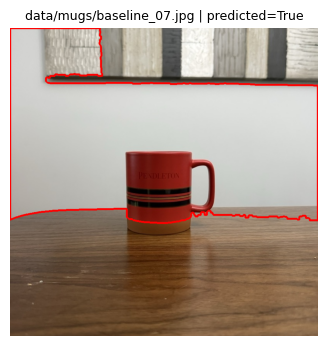

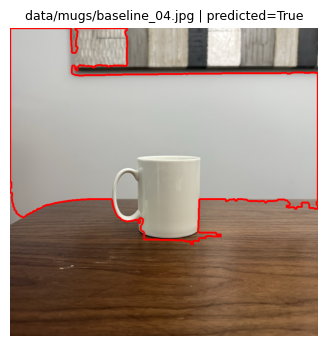

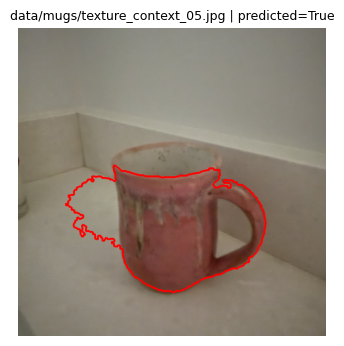

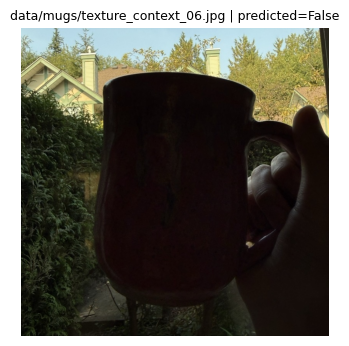

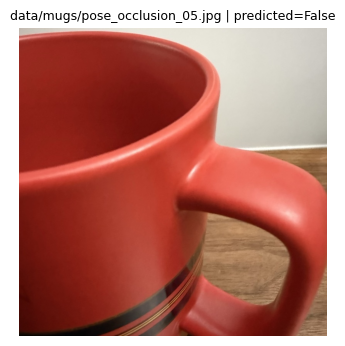

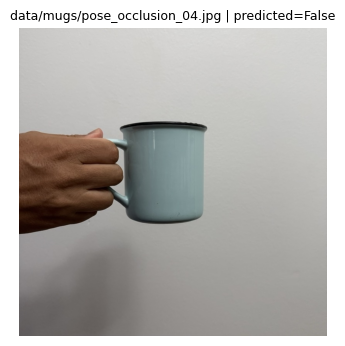

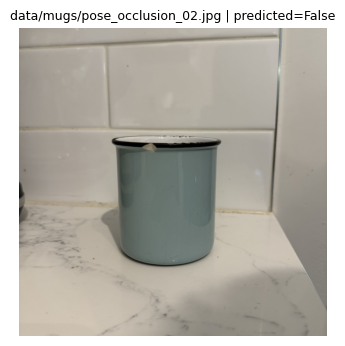

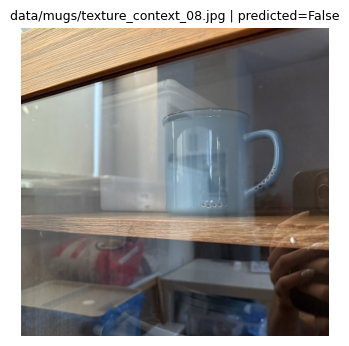

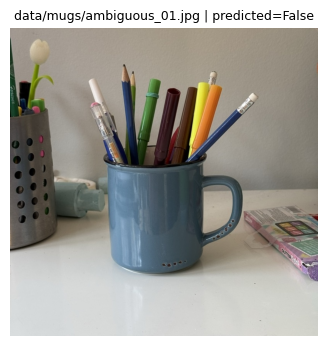

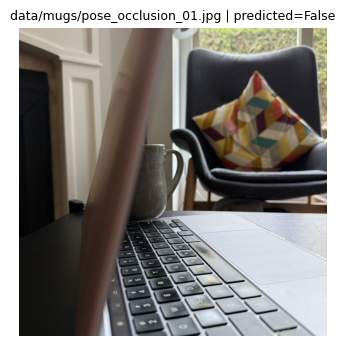

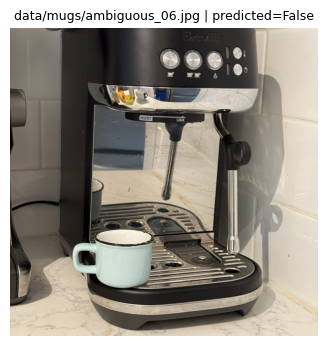

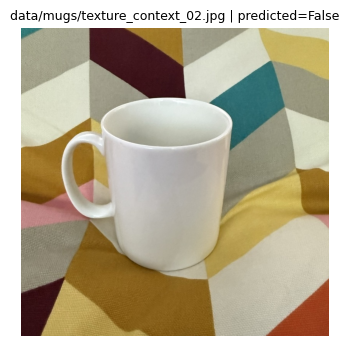

In [22]:
import glob

# A handful of images to try -- feel free to swap these for others in data/labels.csv.
test_images = [
    'mugs/baseline_02.jpg',      # a colored mug
    'mugs/texture_context_01.jpg',  # a trickier background
    'distractors/teapot_01.jpg',    # not a mug at all
]

# test_images = glob.glob('data/**/*.jpg', recursive=True)
test_images = glob.glob('data/mugs/*.jpg', recursive=True)

for rel_path in test_images:
    image = load_image_abs(rel_path)
    result = detect_mug2(image)
    visualize_detection(image, result, title=rel_path)

## Discussion

- What happened when you widened the color range? Did it catch more mugs, or start catching
  things that *aren't* mugs?
- Every fix you make to catch one image tends to risk breaking another. That tension, not any
  single bug, is the real story of rule-based computer vision.

Keep this feeling in mind -- you're about to see how the next two eras deal with it differently.